In [1]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import shutil
from sklearn.cluster import AgglomerativeClustering, AffinityPropagation
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
import cv2
from scipy.ndimage.morphology import binary_erosion
from scipy.ndimage.morphology import binary_dilation
from scipy.ndimage import zoom
from sklearn.mixture import GaussianMixture
import sklearn

/home/users/ilanazs/.local/lib/python3.6/site-packages/ants/viz/render_surface_function.py:16: UserWarning:

Cant import Plotly. Install it `pip install chart_studio` if you want to use ants.render_surface_function



In [2]:
def supervoxel_to_full_res(brain, cluster_labels):
    n_clusters = brain.shape[2]
    n_tp = brain.shape[1]
    brain_dims=[314,146]
    
    reformed_brain = []
    for z in range(brain.shape[0]):
        colored_by_betas = np.zeros((n_tp, brain_dims[0]*brain_dims[1]))
        for cluster_num in range(n_clusters):
            cluster_mask = cluster_labels[z,:]==cluster_num
#             print(cluster_indicies)
            colored_by_betas[:,cluster_mask] = brain[z,:,cluster_num,np.newaxis]
        colored_by_betas = colored_by_betas.reshape(n_tp,brain_dims[0],brain_dims[1])
        reformed_brain.append(colored_by_betas)
    return np.asarray(reformed_brain)
def dual_channel_remove_noise(arr_r, arr_g):
    z,xy,t=np.shape(arr_g)
    flat_red=arr_r.reshape(xy*z,t)
    flat_green=arr_g.reshape(xy*z,t)
    print(flat_green.shape)
    flat_sig=np.zeros_like(flat_green)
    for i in range(np.shape(flat_red)[0]):
        a=np.polyfit(flat_red[i,:],flat_green[i,:],1)
        sig = flat_green[i,:] - (a[0]*flat_red[i,:] + a[1])
        flat_sig[i,:]=sig
    return flat_sig.reshape(z,xy,t)
def make_multi_behave_dict(behaviors,later_dir,step_size,event,ch_num):
    behave_dict = {}
    for behavior in behaviors:
        behave_dir = os.path.join(later_dir, behavior)
        behave_dict[behavior]=[]
        for file in os.listdir(behave_dir):
            if 'STA' in file and str(step_size) in file and event in file and f'_{ch_num}_' in file:
                STA_path=os.path.join(behave_dir, file)
                with h5py.File(STA_path, 'r') as sf:
                    brain = sf['data'][:]
                    brain[np.isnan(brain)] = 0
                    brain[np.isinf(brain)] = 4
                    brain = np.moveaxis(brain, 0, -1)
                    dims=np.shape(brain)
                    print(f'brain {file} shape: {dims}')
                    behave_dict[behavior]=brain
    return behave_dict

def make_supervox_dict(behave_dict, behaviors, n_clusters,cluster_labels):
    supervox_dict={}
    for behave in behaviors:
        supervox_dict[behave]=[]
        brain = behave_dict[behave]
        dims = np.shape(brain)
        for z in range(dims[-2]):
            neural_activity = brain[:,:,z,:].reshape(-1, dims[3])
            signals = []
            for cluster_num in range(n_clusters):
                cluster_indicies = np.where(cluster_labels[z,:]==cluster_num)[0]
                mean_signal = np.mean(neural_activity[cluster_indicies,:], axis=0)
                signals.append(mean_signal)
            signals = np.asarray(signals)
            supervox_dict[behave].append(signals)
        supervox_dict[behave] = np.asarray(supervox_dict[behave])
        print(f'{behave} shape: {np.shape(supervox_dict[behave])}')
    return supervox_dict
def supervoxel_to_full_res(brain, cluster_labels):
    n_clusters = brain.shape[2]
    n_tp = brain.shape[1]
    brain_dims=[314,146]
    
    reformed_brain = []
    for z in range(brain.shape[0]):
        colored_by_betas = np.zeros((n_tp, brain_dims[0]*brain_dims[1]))
        for cluster_num in range(n_clusters):
            cluster_mask = cluster_labels[z,:]==cluster_num
#             print(cluster_indicies)
            colored_by_betas[:,cluster_mask] = brain[z,:,cluster_num,np.newaxis]
        colored_by_betas = colored_by_betas.reshape(n_tp,brain_dims[0],brain_dims[1])
        reformed_brain.append(colored_by_betas)
    return np.asarray(reformed_brain)

In [3]:
### big STA supervox
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')

behaviors = ['total', 'inc', 'dec', 'flat']

n_clusters=2000

step_size=100

event='10flies'

ch_g=2
ch_r=1

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [4]:
giant_cluster_labels = np.load(os.path.join(cluster_dir, 'cluster_labels_best_flies.npy'))

# Load STAs for each behavior and channel

In [5]:
behave_dict_g = make_multi_behave_dict(behaviors,later_dir,step_size,event,ch_g)
behave_dict_r = make_multi_behave_dict(behaviors,later_dir,step_size,event,ch_r)

brain STA_2_total_100_10flies.h5 shape: (314, 146, 91, 24)
brain STA_2_inc_100_10flies.h5 shape: (314, 146, 91, 24)
brain STA_2_dec_100_10flies.h5 shape: (314, 146, 91, 24)
brain STA_2_flat_100_10flies.h5 shape: (314, 146, 91, 24)
brain STA_1_total_100_10flies.h5 shape: (314, 146, 91, 24)
brain STA_1_inc_100_10flies.h5 shape: (314, 146, 91, 24)
brain STA_1_dec_100_10flies.h5 shape: (314, 146, 91, 24)
brain STA_1_flat_100_10flies.h5 shape: (314, 146, 91, 24)


In [6]:
behave_dict_g.keys()

dict_keys(['total', 'inc', 'dec', 'flat'])

# Turn both channel STA dicts into Supervoxels

In [7]:
%%time
supervox_dict_g=make_supervox_dict(behave_dict_g, behaviors, n_clusters,giant_cluster_labels)
supervox_dict_r=make_supervox_dict(behave_dict_r, behaviors, n_clusters,giant_cluster_labels)

total shape: (91, 2000, 24)
inc shape: (91, 2000, 24)
dec shape: (91, 2000, 24)
flat shape: (91, 2000, 24)
total shape: (91, 2000, 24)
inc shape: (91, 2000, 24)
dec shape: (91, 2000, 24)
flat shape: (91, 2000, 24)
CPU times: user 49.1 s, sys: 464 ms, total: 49.6 s
Wall time: 49.6 s


# Remove noise using red channel regression

In [8]:
%%time
supervox_dict_total={}
for behave in behaviors:
    print(behave)
    arr_g=supervox_dict_g[behave]
    arr_r=supervox_dict_r[behave]
    total_behave=dual_channel_remove_noise(arr_r, arr_g)
    supervox_dict_total[behave]=total_behave

total
(182000, 24)
inc
(182000, 24)
dec
(182000, 24)
flat
(182000, 24)
CPU times: user 51.4 s, sys: 1.19 s, total: 52.6 s
Wall time: 51.1 s


# Put the Supervoxs back into anatomical space

In [9]:
%%time
full_res={}
for behave in behaviors:
    print(behave)
#     supervox_brain=lowpass_dict[behave]
#     supervox_brain=gaussian_filter(supervox_dict_total[behave], sigma=1.5)
    supervox_brain=np.moveaxis(supervox_dict_total[behave],-1,-2)
#     print(np.shape(supervox_brain))
    full_res_brain=supervoxel_to_full_res(supervox_brain, giant_cluster_labels)
    full_res_brain=np.moveaxis(full_res_brain, 0,-1)
    full_res_brain=np.moveaxis(full_res_brain, 0,-1)
    print(np.shape(full_res_brain))
    full_res[behave]=np.asarray(full_res_brain)

total
(314, 146, 91, 24)
inc
(314, 146, 91, 24)
dec
(314, 146, 91, 24)
flat
(314, 146, 91, 24)
CPU times: user 48.7 s, sys: 1.25 s, total: 50 s
Wall time: 50 s


In [10]:
fixed = brainsss.load_fda_meanbrain()
brain=full_res['total']
smoothed=gaussian_filter(brain, sigma=1.5)
# masked=np.where(fixed.numpy()[...,None]>0.1, brain, np.nan)
masked=np.where(fixed.numpy()[...,None]>0.1,smoothed, np.nan)

In [11]:
atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, atlas)

In [12]:
%%time

total_vox_sorted={}
for behavior in full_res:
    STA=full_res[behavior]
    total_vox_sorted[behavior]={}
    for area in explosion_rois:
        for key in explosion_rois[area]['rois']:
            area_name=explosion_rois[area]['rois'][key]
            if '_R' in area_name or '_L' in area_name:
                total_area_name=area_name.split('_')
                if len(total_area_name)==3:
                    area_name=total_area_name[0]+'_'+total_area_name[1]
                else:
                    area_name=total_area_name[0]
            roi=key
            roi_mask=roi_masks[roi]
#             print(np.shape(STA))
            masked_roi=[STA[...,i][roi_mask] for i in range(np.shape(STA)[-1])]
            masked_roi=np.transpose(masked_roi)
    #         roi_sort=sort_rows_by_max_index(masked_roi)
            try:
                np.append(total_vox_sorted[behavior][area_name], masked_roi)
            except KeyError:
                total_vox_sorted[behavior][area_name]=masked_roi

CPU times: user 8.19 s, sys: 153 ms, total: 8.34 s
Wall time: 8.34 s


In [13]:
def moving_average_2d(arr):
    num_bins=np.shape(arr)[-1]
    window_size=int(num_bins/5)
    # Apply uniform filter to compute the moving average
    return uniform_filter(arr, size=window_size, mode='constant')

def sort_rows_by_max_index(arr):
#     smoothed_row=moving_average_2d(arr)
    max_stim=[]
    max_not_stim=[]
    for i,row in enumerate(arr):
        loc=np.where(row==np.nanmax(row))[0][0]
    #     print(loc)
        if loc>6:
            max_stim.append(arr[i])
        else:
            max_not_stim.append(arr[i])
    max_stim=np.asarray(max_stim)
    max_not_stim=np.asarray(max_not_stim)

    max_indices_stim = np.nanargmax(max_stim, axis=1)
    sorted_order_stim = np.argsort(max_indices_stim)
    sorted_arr_stim = max_stim[sorted_order_stim,:]

    if max_not_stim.size>0:
        sorted_arr=np.vstack([sorted_arr_stim,max_not_stim])
    else:
        sorted_arr=np.vstack(sorted_arr_stim)

    return sorted_arr

In [14]:
%%time
for behavior in total_vox_sorted:
    for key in total_vox_sorted[behavior]:
        total_vox_sorted[behavior][key]=sort_rows_by_max_index(total_vox_sorted[behavior][key])

CPU times: user 20.8 s, sys: 377 ms, total: 21.1 s
Wall time: 20.6 s


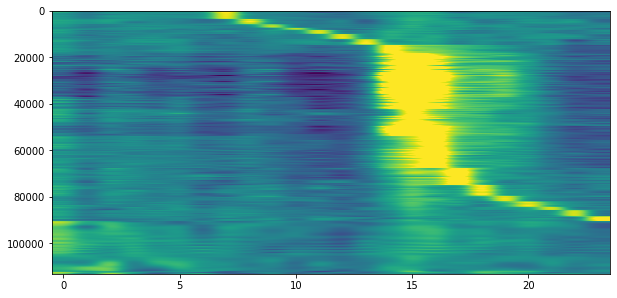

In [15]:
fig,axs=plt.subplots(figsize=(10,10))
axs.imshow(total_vox_sorted[behavior]['MED'],vmax=0.03, vmin=-0.03, interpolation='gaussian');
axs.set_aspect(0.0001)

In [16]:
def plot_heatmap_area(areas_dict, area, ax, step_size, heights=None, vmax=0.01, vmin=-0.01,cmap='magma'):
    if step_size==10:
        stuff=np.array([[0.00006,-0.00002],[60,160]])
    elif step_size==5:
        stuff=np.array([[0.4,-0.003],[0.5,2.5]])
    elif step_size==20:
        stuff=np.array([[0.008,-0.008],[30,80]])
    elif step_size==100:
        stuff=np.array([[0.01,-0.003],[6,16]])
#     area_smooth=gaussian_filter(areas_dict[area], sigma=1.5)
    ax.imshow(areas_dict[area],vmax=vmax, vmin=vmin, cmap=cmap, interpolation='gaussian') #vmax=stuff[0,0], vmin=stuff[0,1], 
    ax.set_ylabel(area, rotation=0, labelpad=20)
    ax.axvline(x=stuff[1,0], ymin=0, ymax=1, ls='--', color='w', lw=2)
    ax.axvline(x=stuff[1,1], ymin=0, ymax=1, ls='--', color='w', lw=2)
    if heights!=None:
        median=np.median(list(heights.values()))
        if heights[area]<=median:
            ax.set_aspect(heights[area])
        else:
            ax.set_aspect('auto')
    else:
        ax.set_aspect('auto')
    ax.set_yticks([])

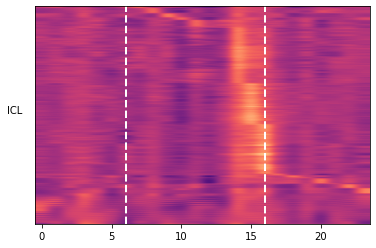

In [17]:
brain=total_vox_sorted['total']
# fig, axs = plt.subplots()
# anat='MED'
# plot_heatmap_area(brain, anat, axs, step_size, heights=heights)
# plt.savefig(os.path.join(save_dir,f'{anat}_heatmap_{step_size}.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'{anat}_heatmap_{step_size}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
fig, axs = plt.subplots()
anat='ICL'
plot_heatmap_area(brain, anat, axs, step_size=100, heights=None, vmax=0.02, vmin=-0.02)
# plt.savefig(os.path.join(save_dir,f'{anat}_heatmap_{step_size}.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'{anat}_heatmap_{step_size}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

In [18]:
print(np.nanmax(total_vox_sorted[behavior]['MED']))
print(np.nanmin(total_vox_sorted[behavior]['MED']))
print(np.nanmedian(total_vox_sorted[behavior]['MED']))

0.20895306766033173
-0.0933627188205719
-0.0013705086894333363


In [19]:
print(np.nanmax(total_vox_sorted[behavior]['MED'][60000]))
print(np.nanmax(total_vox_sorted[behavior]['MED'][40000]))
print(np.nanmax(total_vox_sorted[behavior]['MED'][10000]))

0.02545226737856865
0.036110348999500275
0.04401141405105591


In [20]:
total_vox_sorted[behavior].keys()

dict_keys(['FB', 'NO', 'BU', 'LAL', 'PVLP', 'VES', 'EPA', 'GOR', 'AMMC', 'PB', 'EB', 'PRW', 'SAD', 'GNG', 'AVLP', 'AL', 'MB_PED', 'MB_VL', 'MB_ML', 'MB_CA', 'IVLP', 'CAN', 'FLA', 'SLP', 'SMP', 'PLP', 'LH', 'IPS', 'SPS', 'CRE', 'SCL', 'ICL', 'ATL', 'IB', 'SIP', 'MED', 'LO', 'LP', 'AOTU'])

In [21]:
def get_rois(explosion_rois, roi_group, roi_masks, data_to_plot, roi_contours, vmax, cmap, diverging, roi=None):
    x_shift = explosion_rois[roi_group]['x_shift']
    y_shift = explosion_rois[roi_group]['y_shift']

    roi_data = []
    left_edges = []
    right_edges = []
    bottom_edges = []
    top_edges = []

    if roi==None:
        for roi in explosion_rois[roi_group]['rois']:
            mask = roi_masks[roi]
            masked_roi = mask[...,np.newaxis]*data_to_plot # for 3 channel
#             masked_roi = mask*data_to_plot

            ### maximum projection along z-axis
            # works for negative values
            maxs = np.max(masked_roi,axis=2)
            mins = np.min(masked_roi,axis=2)
            maxs[np.where(np.abs(mins)>maxs)] = mins[np.where(np.abs(mins)>maxs)]
            roi_data.append(maxs)
            #masked_roi_flat = maxs

            ### maximum projection along z-axis
            #masked_roi_flat = np.max(masked_roi,axis=2)
            #roi_data.append(masked_roi_flat)

            left_edges.append(roi_contours[roi]['left_edge'])
            right_edges.append(roi_contours[roi]['right_edge'])
            top_edges.append(roi_contours[roi]['top_edge'])
            bottom_edges.append(roi_contours[roi]['bottom_edge'])
    else:
        mask = roi_masks[roi]
        masked_roi = mask[...,np.newaxis]*data_to_plot # for 3 channel
#         masked_roi = mask*data_to_plot

        ### maximum projection along z-axis
        # works for negative values
        maxs = np.max(masked_roi,axis=2)
        mins = np.min(masked_roi,axis=2)
        maxs[np.where(np.abs(mins)>maxs)] = mins[np.where(np.abs(mins)>maxs)]
        roi_data.append(maxs)
        #masked_roi_flat = maxs

        ### maximum projection along z-axis
        #masked_roi_flat = np.max(masked_roi,axis=2)
        #roi_data.append(masked_roi_flat)

        left_edges.append(roi_contours[roi]['left_edge'])
        right_edges.append(roi_contours[roi]['right_edge'])
        top_edges.append(roi_contours[roi]['top_edge'])
        bottom_edges.append(roi_contours[roi]['bottom_edge'])


    # get extreme edges from all rois used
    left_edge = np.min(left_edges) - 1
    right_edge = np.max(right_edges) + 1
    top_edge = np.min(top_edges) - 1
    bottom_edge = np.max(bottom_edges) + 1

    ### this projects across all the roi_data from each roi 
    #roi_datas = np.max(np.asarray(roi_data),axis=0) # this one line is sufficient for not diverging
    maxs = np.max(np.asarray(roi_data),axis=0)
    mins = np.min(np.asarray(roi_data),axis=0)
    maxs[np.where(np.abs(mins)>maxs)] = mins[np.where(np.abs(mins)>maxs)]
    roi_datas = maxs

    ###ADD MAX MIN HERE LIKE ABOVE

    ### cutout this grouping
    #data_map = np.swapaxes(roi_datas[top_edge:bottom_edge,left_edge:right_edge,:],0,1) # for 3 channel
    data_map = np.swapaxes(roi_datas[top_edge:bottom_edge,left_edge:right_edge],0,1)
    ### apply gain
    #data_map = data_map * gain

    mycmap = matplotlib.cm.get_cmap(cmap)
    #mycmap.set_bad('k',1) # make nans black

    if diverging:
        # this will normalize all value to [0,1], with 0.5 being the new "0" basically
        # current issue - a zero that should be background now looks like negative.
        # solution: could use nans instead and set bad color
        # with diverging we should make background white!
        # so actually just set the input_canvas as 0.5!!!
        # then make contours nan and set back as black
        norm = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax)
        data_map = norm(data_map)
    else:
        data_map = data_map/vmax

    data_map = mycmap(data_map)[...,:3] #lose alpha channel

#     dims = get_dim_info(data_map, full_x_mid, full_y_mid)
    return data_map

In [22]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

top_color=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7'])[::-1]
bottom=np.asarray(['#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
top_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
    'top_half_spect', top_color)
bottom_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
    'bottom_half_spect', bottom)

# Register the new colormap
plt.register_cmap(cmap=top_half_spect)
plt.register_cmap(cmap=bottom_half_spect)

In [23]:
def mean_edges(flattened):
    mean_line=np.nanmean(flattened)
    std=np.nanstd(flattened)
    neg_edge=mean_line-std
    pos_edge=mean_line+std
    return mean_line, neg_edge, pos_edge

In [24]:
t,x,y,z=np.shape(full_res[behavior])
flatten=np.asarray(full_res[behavior]).reshape(x*y*z,t)

In [25]:
m,n,p=mean_edges(flatten)

In [26]:
np.mean(flatten)

-2.0289414421396785e-14

In [27]:
roi_label_dict={}
for area in explosion_rois:
    rois=explosion_rois[area]['rois']
    shifts=[explosion_rois[area]['x_shift'], explosion_rois[area]['y_shift']]
    for roi in rois:
        name=rois[roi]
        if area!=name:
            group=area
        else:
            group=name
        roi_label_dict[name]={}
        roi_label_dict[name]['label']=roi
        roi_label_dict[name]['shifts']=shifts
        roi_label_dict[name]['group']=group
            
    

In [28]:
roi_label_dict.keys()

dict_keys(['FB', 'NO', 'BU_R', 'BU_L', 'LAL_R', 'LAL_L', 'PVLP_R', 'PVLP_L', 'VES_R', 'EPA_R', 'GOR_R', 'AMMC_R', 'VES_L', 'EPA_L', 'GOR_L', 'AMMC_L', 'PB', 'EB', 'PRW', 'SAD', 'GNG', 'AVLP_R', 'AVLP_L', 'AL_R', 'AL_L', 'MB_PED_L', 'MB_VL_L', 'MB_ML_L', 'MB_CA_L', 'MB_PED_R', 'MB_VL_R', 'MB_ML_R', 'MB_CA_R', 'IVLP_R', 'IVLP_L', 'CAN_R', 'FLA_R', 'CAN_L', 'FLA_L', 'SLP_R', 'SMP_R', 'PLP_R', 'LH_R', 'IPS_R', 'SPS_R', 'CRE_R', 'SCL_R', 'ICL_R', 'ATL_R', 'IB_R', 'SIP_R', 'SLP_L', 'SMP_L', 'PLP_L', 'LH_L', 'IPS_L', 'SPS_L', 'CRE_L', 'SCL_L', 'ICL_L', 'ATL_L', 'IB_L', 'SIP_L', 'MED_R', 'MED_L', 'LO_R', 'LO_L', 'LP_R', 'LP_L', 'AOTU_R', 'AOTU_L'])

In [29]:
np.shape(full_res['total'])

(314, 146, 91, 24)

In [30]:
def get_vals_anat(roi, roi_label_dict, roi_masks, traces, behavior, roi_contours, vmax, thresh=None):
    x_shift = roi_label_dict[roi]['shifts'][0]
    y_shift = roi_label_dict[roi]['shifts'][1]

    left_edges = []
    right_edges = []
    bottom_edges = []
    top_edges = []
    
    roi_label=roi_label_dict[roi]['label']
    mask = roi_masks[roi_label]
    masked_roi = np.where(mask[...,None]==True, traces[behavior], np.nan)
#     t,x,y,z=np.shape(masked_roi)
    x,y,z,t=np.shape(traces[behavior])
#     flatten=np.asarray(masked_roi).reshape(x*y*z,t)
    flatten=np.asarray(traces[behavior]).reshape(x*y*z,t)
    m,n,p=mean_edges(flatten)
    
    if thresh=='pos':
        total_masked=np.where(masked_roi>p*1,masked_roi, np.nan)
#         print(p)
    elif thresh=='neg':
        total_masked=np.where(masked_roi<n*1,masked_roi, np.nan)
#         print(n)
    else:
        total_masked=np.where(masked_roi>thresh,masked_roi, np.nan)
    
    left_edges.append(roi_contours[roi_label]['left_edge'])
    right_edges.append(roi_contours[roi_label]['right_edge'])
    top_edges.append(roi_contours[roi_label]['top_edge'])
    bottom_edges.append(roi_contours[roi_label]['bottom_edge'])
    
    # get extreme edges from all rois used
    left_edge = np.min(left_edges) - 1
    right_edge = np.max(right_edges) + 1
    top_edge = np.min(top_edges) - 1
    bottom_edge = np.max(bottom_edges) + 1
    
    final=total_masked[top_edge:bottom_edge,left_edge:right_edge]
#     if vmax!=None:
#         norm = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax)
#         final = norm(final)

    contour = roi_contours[roi_label]['contour'][...,0]
    contour = contour[top_edge:bottom_edge,left_edge:right_edge]
    
    return final, contour

In [31]:
anat='AVLP_R'
behave='total'
direction='pos'
total_anat_max, contour_max=get_vals_anat(anat, roi_label_dict, roi_masks, full_res, behave, roi_contours, vmax=None, thresh=direction)

In [32]:
direction='neg'
total_anat_min, contour_min=get_vals_anat(anat, roi_label_dict, roi_masks, full_res, behave, roi_contours, vmax=None, thresh=direction)

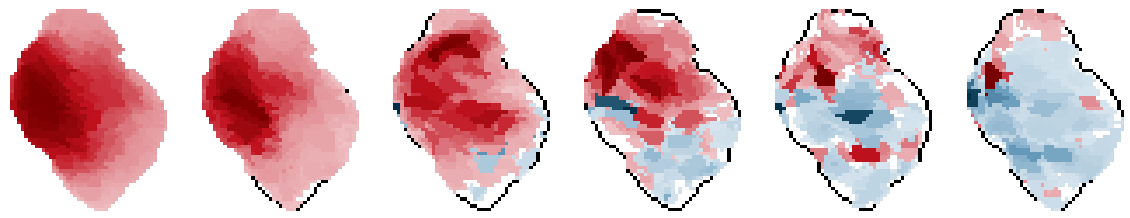

In [33]:
# ts=[6,7,8,9,10,11,12,13,14,15]
# ts=[6,10,12,14,15]
ts=[16,17,18,19,20,21]
num_reg=np.shape(ts)[0]
fig, axs=plt.subplots(1,num_reg,figsize=(20,20))
for j,t in enumerate(ts):
#     print(f'j:{j}, t:{t}')
    
    x,y=np.nanmax(total_anat_max[...,t],axis=-1).shape
    max_t=np.ravel(np.nanmax(total_anat_max[...,t],axis=-1))
    min_t=np.ravel(np.nanmin(total_anat_min[...,t],axis=-1))
    for i in range(min_t.shape[0]):
        if ~np.isnan(max_t[i]) and ~np.isnan(min_t[i]):
            if np.abs(max_t[i])>np.abs(min_t[i]):
                min_t[i]=np.nan
            elif np.abs(max_t[i])<np.abs(min_t[i]):
                max_t[i]=np.nan
    final_max=max_t.reshape(x,y)
    final_min=min_t.reshape(x,y)
    axs[j].imshow(contour_max.T, 'Greys');

    axs[j].imshow(final_min.T, cmap=bottom_half_spect);
    axs[j].imshow(final_max.T,cmap=top_half_spect);

    axs[j].axis('off');
# plt.savefig(os.path.join(save_dir,f'{anat}_{step_size}_{t}.png'), dpi=300, bbox_inches='tight')
    # plt.savefig(os.path.join(save_dir,f'{anat}_{pix_type}_{step_size}_{t}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

In [34]:
def place_roi_groups_on_canvas(explosion_rois, roi_masks, roi_contours, data_to_plot, input_canvas, vmax, cmap, rois, diverging=False):
    full_y_mid = int(input_canvas.shape[0]/2)
    full_x_mid = int(input_canvas.shape[1]/2)
    
    for roi_group in explosion_rois:
        
        x_shift = explosion_rois[roi_group]['x_shift']
        y_shift = explosion_rois[roi_group]['y_shift']
        
        roi_data = []
        left_edges = []
        right_edges = []
        bottom_edges = []
        top_edges = []
        
        for roi in explosion_rois[roi_group]['rois']:
            mask = roi_masks[roi]
            name=explosion_rois[roi_group]['rois'][roi]
            last = name.split("_")[-1]
            removed=name.replace(f'_{last}', '')
            if removed in rois:
                masked_roi = mask*1
            else:
                # Change this line: set to NaN instead of 0
                masked_roi = mask*np.nan

            ### maximum projection along z-axis
            # Use nanmax and nanmin to handle NaN values properly
            maxs = np.nanmax(masked_roi,axis=2)
            mins = np.nanmin(masked_roi,axis=2)
            maxs[np.where(np.abs(mins)>maxs)] = mins[np.where(np.abs(mins)>maxs)]
            roi_data.append(maxs)
            
            left_edges.append(roi_contours[roi]['left_edge'])
            right_edges.append(roi_contours[roi]['right_edge'])
            top_edges.append(roi_contours[roi]['top_edge'])
            bottom_edges.append(roi_contours[roi]['bottom_edge'])
        
        # get extreme edges from all rois used
        left_edge = np.min(left_edges) - 1
        right_edge = np.max(right_edges) + 1
        top_edge = np.min(top_edges) - 1
        bottom_edge = np.max(bottom_edges) + 1
        
        ### Use nanmax and nanmin here too
        maxs = np.nanmax(np.asarray(roi_data),axis=0)
        mins = np.nanmin(np.asarray(roi_data),axis=0)
        maxs[np.where(np.abs(mins)>maxs)] = mins[np.where(np.abs(mins)>maxs)]
        roi_datas = maxs

        ### cutout this grouping
        data_map = np.swapaxes(roi_datas[top_edge:bottom_edge,left_edge:right_edge],0,1)

        mycmap = matplotlib.cm.get_cmap(cmap)
        mycmap.set_bad(alpha=0)  # This will now work with NaN values

        if diverging:
            norm = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax)
            data_map = norm(data_map)
        else:
            data_map = data_map/vmax
        
        data_map = mycmap(data_map)  # Keep alpha channel this time

        dims = brainsss.get_dim_info(data_map, full_x_mid, full_y_mid)

        ### ADD TO CANVAS - handle alpha channel
        canvas_region = input_canvas[dims['top']+y_shift:dims['bottom']+y_shift,
                                   dims['left']+x_shift:dims['right']+x_shift, :3]
        
        # Only update pixels where alpha > 0 (non-transparent)
        alpha_mask = data_map[..., 3] > 0
        canvas_region[alpha_mask] = data_map[alpha_mask, :3]
        
        ### ADD CONTOUR TO CANVAS
        for roi in explosion_rois[roi_group]['rois']:
            contour = roi_contours[roi]['contour']
            contour = np.swapaxes(contour[top_edge:bottom_edge,left_edge:right_edge],0,1)
            ys = np.where(contour[:,:,0]>0)[0] + dims['top'] + y_shift
            xs = np.where(contour[:,:,0]>0)[1] + dims['left'] + x_shift
            input_canvas[ys,xs]=0
    return input_canvas

In [35]:
data=np.moveaxis(full_res['total'],-1,0)
print(data.shape)

(24, 314, 146, 91)


In [1]:
rainbow_color=np.asarray(['#EF476F', '#F78C6B', '#FFD166', '#06D6A0', '#118AB2', '#6A4C93'])
this_color=['#FFFFFF','#EF476F']
cmap_this_color = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', this_color)

NameError: name 'np' is not defined

In [37]:
rois=['MB_VL']
input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
data_to_plot = data[15][:,:,::-1]
vmax = 0.5
explosion_map=place_roi_groups_on_canvas(explosion_rois,roi_masks,
                           roi_contours,
                           data_to_plot,
                           input_canvas,
                           vmax=0.1,
                           rois=rois,
                           cmap=cmap_this_color, diverging=False)

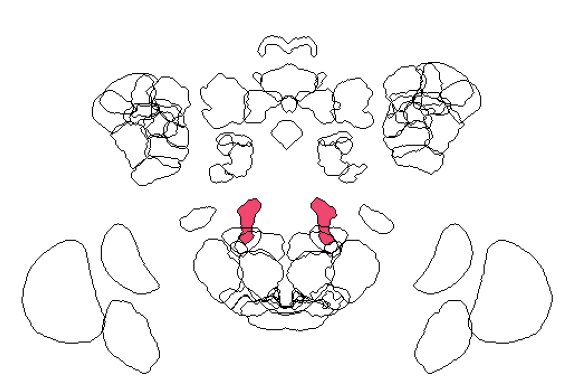

In [38]:

plt.figure(figsize=(10,10));
plt.imshow(explosion_map[170:,:]);
plt.axis('off');
# plt.savefig(os.path.join(save_dir,f'{rois[0]}_map.png'), dpi=300, bbox_inches='tight', transparent=True)